In [1]:
!pip install pgmpy pygad scikit-learn fairlearn networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nv

In [25]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import networkx as nx
import gc

from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    true_positive_rate_difference,
    false_positive_rate_difference,
    MetricFrame
)

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator, HillClimbSearch, BayesianEstimator
from pgmpy.inference import VariableElimination


In [3]:
def preprocessAdultIncome():
    data = pd.read_csv('/kaggle/input/adult-census-income/adult.csv') #load dataset
    # print(data.columns)
    categorical_cols = ['workclass', 'education', 'marital.status', 'occupation',
                    'relationship', 'race', 'sex', 'native.country']
    numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
    data["income"] = np.where(data["income"] == ">50K", 1, 0) #convert to binary vals
    # print(data.head())
    column_names = data.columns
    # for i in column_names: #this was to see the missing vals
        # print(i,(data[i] == '?').sum()) #workclass, occupation and native.country have ? vals
    missing_vals = data.isin(['?']).any(axis=1) #find missing vals 
    # print(data[missing_vals]['income'].value_counts()) #see how many missing vals are there in each class, doesnt matter that much, the difference
    data = data[~missing_vals] #drop missing vals
    data.reset_index(drop=True, inplace=True)
    # print(data["income"].value_counts())
    #below is for proportional upsampling
    more_50k = data[data['income']==1] #all that is 1 vals
    # print(more_50k.groupby(['race','sex']).size()) #how many vals by each of the race and sex group
    dist = more_50k.groupby(['race','sex']).size().reset_index(name='count') #this is the count of the current distribution of vals 
    # print((dist['count']*22654/dist['count'].sum()).round().astype(int))
    dist['up_count'] = (dist['count']*22654/dist['count'].sum()).round().astype(int) #calulates to what rate we need to upsample to keep the proportion of bias and reach the goal no of samples
    # print(dist.head())
    upsampled_list = []
    for _,row in dist.iterrows():
        sex = row["sex"]
        race = row["race"]
        up_count = row["up_count"]
        group_df = more_50k[(more_50k['sex']==sex) & (more_50k['race']==race)] #group for a particular race and sex combo
        upsampled_group = resample(group_df, replace = True, n_samples = up_count, random_state = 42) #resample to reach the up_count
        upsampled_list.append(upsampled_group)
    upsampled_more_than_50k = pd.concat(upsampled_list)
    less_than_50k = data[data['income']==0]
    df = pd.concat([less_than_50k,upsampled_more_than_50k]).sample(frac=1,random_state=42).reset_index(drop=True) #concat with shuffle (frac=1 makes it so all of the samples are considered)
    df.head()
    print(df["income"].value_counts())
    print(df['sex'].value_counts())
    #preprocessing pipeline
    numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('category', OneHotEncoder(handle_unknown='ignore'))])
    preprocessor = ColumnTransformer(transformers=[
        ('num',numeric_transformer,numeric_cols),
        ('cat',categorical_transformer,categorical_cols)
    ])
    #mapping sensitive attributes but not using it for first pass
    #IS THIS ALREADY ONE HOT ENCODED?????????????????
    race_mapping = {"White": 0,"Black": 1,"Asian-Pac-Islander": 2,"Amer-Indian-Eskimo": 3,"Other": 4}
    sensitive_race = df["race"].map(race_mapping)
    sex_mapping = {"Male": 0, "Female": 1}
    sensitive_sex = df["sex"].map(sex_mapping)
    #train test split
    X = df.drop(["income"],axis=1)
    y = df["income"].values
    X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sensitive_race_train, sensitive_race_test = train_test_split(sensitive_race, test_size=0.2, random_state=42, stratify=y)
    sensitive_sex_train, sensitive_sex_test = train_test_split(sensitive_sex, test_size=0.2, random_state=42, stratify=y)
    #implement the preprocessing
    X_train = preprocessor.fit_transform(X_train)
    X_test = preprocessor.transform(X_test)
    return X_train, X_test, y_train, y_test, sensitive_race_train, sensitive_race_test, sensitive_sex_train, sensitive_sex_test 


In [4]:
X_train, X_test, y_train, y_test, sensitive_race_train, sensitive_race_test, sensitive_sex_train, sensitive_sex_test = preprocessAdultIncome()

income
1    22654
0    22654
Name: count, dtype: int64
sex
Male      33283
Female    12025
Name: count, dtype: int64


**AUR METRICS GHUSAANE HAI TOH GHUSAOOO**

In [5]:
def four_metrics(y_test, y_pred, sensitive_race_test, sensitive_sex_test):
    race_metrics = {
        "Demographic Parity Difference": demographic_parity_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_race_test),
        "Equalized Odds Difference": equalized_odds_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_race_test),
        "Equal Opportunity Difference": true_positive_rate_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_race_test),
        "False Positive Rate Difference": false_positive_rate_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_race_test)
    }
    sex_metrics = {
        "Demographic Parity Difference": demographic_parity_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_sex_test),
        "Equalized Odds Difference": equalized_odds_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_sex_test),
        "Equal Opportunity Difference": true_positive_rate_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_sex_test),
        "False Positive Rate Difference": false_positive_rate_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_sex_test)
    }
    return race_metrics, sex_metrics

**WE SHOULD CONSIDER CHANGING THE BASE MODEL TO NEURAL NET YK**

In [6]:
def base_model():
    print("THIS IS BASE MODEL.")
    base_model = LogisticRegression(max_iter=1000,random_state=42)
    base_model.fit(X_train,y_train)
    base_model_pred= base_model.predict(X_test)
    print("Accuracy", accuracy_score(y_test,base_model_pred))
    # print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    # print("Classification Report:\n", classification_report(y_test, y_pred))
    met_race, met_sex = four_metrics(y_test, base_model_pred, sensitive_race_test, sensitive_sex_test)
    print("Fairness metrics for Race:")
    for metric_name, value in met_race.items():
        print(f"{metric_name}: {value:.3f}")
    print("Fairness metrics for Sex:")
    for metric_name, value in met_sex.items():
        print(f"{metric_name}: {value:.3f}")
    return base_model_pred
base_model_pred = base_model()

THIS IS BASE MODEL.
Accuracy 0.8177002869123814
Fairness metrics for Race:
Demographic Parity Difference: 0.370
Equalized Odds Difference: 0.280
Equal Opportunity Difference: 0.146
False Positive Rate Difference: 0.280
Fairness metrics for Sex:
Demographic Parity Difference: 0.373
Equalized Odds Difference: 0.226
Equal Opportunity Difference: 0.141
False Positive Rate Difference: 0.226



**Below is the aggresive hard reweighting we applied before. can we implement a softer reweighting if need be?also how does it get worse for eq odds and eq opportunity? i think its because of the tpr, how can we fix that? is this a fair tradeoff?**


In [7]:
def hard_reweighting(y_pred):
    adjusted_preds = y_pred.copy()
    for sensitive_attr in [sensitive_race_test, sensitive_sex_test]:
        #group is group within a sensitive atrr
        df = pd.DataFrame({'group': sensitive_attr, 'pred': adjusted_preds})
        # print(df.sample(10))
        selection_rates = df.groupby('group')['pred'].mean()
        #this is basically the num of 1's for a particular group, this is supposed to indicate how many times a part grp gets picked on an avg
        # print(selection_rates)
        target_rate = selection_rates.mean()
        #mean of all selection rates is our target
        # print(target_rate)
        for group, rate in selection_rates.items():
            # print("group,rate", group,rate)
            adjustment = target_rate - rate
            idxs = np.where(df['group'] == group)[0]
            #indices of the part group wherver they are
            group_preds = adjusted_preds[idxs] #only preds of that group are in this var
            if adjustment > 0: #+ve adjustment -> need to reduce 1's, pick 0 as candidate
                flip_candidates = idxs[group_preds == 0]
            else: #-ve adjustment -> need to increase 1's, pick 1 as candidate
                flip_candidates = idxs[group_preds == 1]
            #num to flip is how many predictions to actually flip 
            #1st candidate is adjs rate * total (basically diff in num)
            #2nd is total preds that fit the criteria (i.e all 0s or 1s)
            num_to_flip = min(int(abs(adjustment) * len(idxs)), len(flip_candidates))
            if num_to_flip > 0:
                #randomly pick WHICH candidates to flip, but we calc the NUM OF CANDIDATES to flip
                np.random.seed(42)
                flip_idxs = np.random.choice(flip_candidates, size=num_to_flip, replace=False)
                adjusted_preds[flip_idxs] = 1 if adjustment > 0 else 0
    return adjusted_preds


In [8]:
print("HARD STATISTICAL REWEIGHTING")
adjusted_hard_preds = hard_reweighting(base_model_pred)
print("Accuracy", accuracy_score(y_test,adjusted_hard_preds))
met_race, met_sex = four_metrics(y_test, adjusted_hard_preds, sensitive_race_test, sensitive_sex_test)
print("Fairness metrics for Race:")
for metric_name, value in met_race.items():
    print(f"{metric_name}: {value:.3f}")
print("Fairness metrics for Sex:")
for metric_name, value in met_sex.items():
    print(f"{metric_name}: {value:.3f}")

HARD STATISTICAL REWEIGHTING
Accuracy 0.6412491723681306
Fairness metrics for Race:
Demographic Parity Difference: 0.083
Equalized Odds Difference: 0.219
Equal Opportunity Difference: 0.219
False Positive Rate Difference: 0.080
Fairness metrics for Sex:
Demographic Parity Difference: 0.000
Equalized Odds Difference: 0.151
Equal Opportunity Difference: 0.151
False Positive Rate Difference: 0.058


> i have to check, the split of train test and even of sensitive attr. the train set isnt used anywhere cause it needs the size to be the same, so i just end up using the test set everywhere. i have to check

In [12]:
def create_fairness_model(input_dim, embedding_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(64, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    embeddings = tf.keras.layers.Dense(embedding_dim, activation='relu', name='embeddings')(x)
    x = tf.keras.layers.Dropout(0.3)(embeddings)
    x = tf.keras.layers.Dense(16, activation='relu')(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    encoder = tf.keras.Model(inputs=inputs, outputs=embeddings)
    return model, encoder

In [26]:
fair_main_model, encoder = create_fairness_model(input_dim=X_train.shape[1],embedding_dim=8)
embeddings = encoder.predict(X_train)

1133/1133 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [15]:
embedding_cols = [f'emb_{i}' for i in range(embeddings.shape[1])]
emb_data = pd.DataFrame(embeddings, columns=embedding_cols)
emb_data['sex'] = pd.Series(sensitive_sex_train).reset_index(drop=True)
emb_data['race'] = pd.Series(sensitive_race_train).reset_index(drop=True)
emb_data['income'] = pd.Series(y_train).reset_index(drop=True)
print(emb_data.head())

      emb_0  emb_1     emb_2     emb_3     emb_4    emb_5     emb_6     emb_7  \
0  0.412804    0.0  0.181423  0.000000  0.158636  0.00000  0.014998  0.000000   
1  0.318343    0.0  0.123019  0.243622  0.085465  0.05020  0.000000  0.000000   
2  0.151524    0.0  0.000000  0.000000  0.273614  0.00000  0.000000  0.001245   
3  0.260864    0.0  0.238506  0.000000  0.117014  0.07324  0.000000  0.000000   
4  0.444212    0.0  0.031113  0.000000  0.434812  0.00000  0.061410  0.000000   

   sex  race  income  
0    0     0       1  
1    1     0       0  
2    0     1       0  
3    1     0       0  
4    0     0       1  


In [16]:
def discretize_column(col, bins=3):
    return pd.cut(col, bins, labels=False)
#we can tune the number of bins

for col in embedding_cols:
    emb_data[col] = discretize_column(emb_data[col], bins=3)
# Since 'income' and 'sex' are binary, we don't discretize them, just convert to int
emb_data['income'] = emb_data['income'].astype(int)
emb_data['sex'] = emb_data['sex'].astype(int)

In [17]:
# -------------------------------
# Build BBN for predicting 'sex'
# -------------------------------

#OBVS THIS STRUCTURE IS HARD CODED AND NOT LEARNT, WE'LL SEE ABOUT THAT
structure_sex = [(col, 'sex') for col in embedding_cols] + [('income', 'sex')]
bbn_sex = DiscreteBayesianNetwork(structure_sex)
bbn_sex.fit(emb_data[embedding_cols + ['income', 'sex']], estimator=MaximumLikelihoodEstimator)
assert bbn_sex.check_model()

# -------------------------------
# Build BBN for predicting 'race'
# -------------------------------
structure_race = [(col, 'race') for col in embedding_cols] + [('income', 'race')]
bbn_race = DiscreteBayesianNetwork(structure_race)
bbn_race.fit(emb_data[embedding_cols + ['income', 'race']], estimator=MaximumLikelihoodEstimator)
assert bbn_race.check_model()


In [18]:
# -------------------------------
# Inference helper functions
# -------------------------------
#we'll see if this needs refactoring
def embedding_to_evidence(embedding_vector, income_value):
    evidence = {}
    for i, val in enumerate(embedding_vector):
        bins = np.histogram(emb_data[f'emb_{i}'], bins=3)[1]
        bin_idx = int(np.digitize(val, bins) - 1)
        evidence[f'emb_{i}'] = max(0, min(2, bin_idx))  # clamp to valid bin range
    evidence['income'] = int(income_value) if emb_data['income'].nunique() == 2 else \
                         int(np.digitize(income_value, np.histogram(emb_data['income'], bins=3)[1]) - 1)
    return evidence

def predict_sensitive_probs(bbn, embedding_vector, income_value, target):
    inference = VariableElimination(bbn)
    evidence = embedding_to_evidence(embedding_vector, income_value)
    return inference.query(variables=[target], evidence=evidence)

# -------------------------------
# Example Inference
# -------------------------------
embedding_example = embeddings[0]
income_example = y_train[0]

# Predict 'sex' distribution
result_sex = predict_sensitive_probs(bbn_sex, embedding_example, income_example, 'sex')
print("Predicted sex distribution:", result_sex)

# Predict 'race' distribution
result_race = predict_sensitive_probs(bbn_race, embedding_example, income_example, 'race')
print("Predicted race distribution:", result_race)


Predicted sex distribution: +--------+------------+
| sex    |   phi(sex) |
+========+============+
| sex(0) |     0.8019 |
+--------+------------+
| sex(1) |     0.1981 |
+--------+------------+
Predicted race distribution: +---------+-------------+
| race    |   phi(race) |
+=========+=============+
| race(0) |      0.9048 |
+---------+-------------+
| race(1) |      0.0466 |
+---------+-------------+
| race(2) |      0.0413 |
+---------+-------------+
| race(3) |      0.0049 |
+---------+-------------+
| race(4) |      0.0024 |
+---------+-------------+


In [19]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_bbn(bbn, title='Bayesian Network'):
    plt.figure(figsize=(10, 6))
    G = nx.DiGraph()
    G.add_edges_from(bbn.edges())
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=12, font_weight='bold', edge_color='gray')
    plt.title(title)
    plt.show()


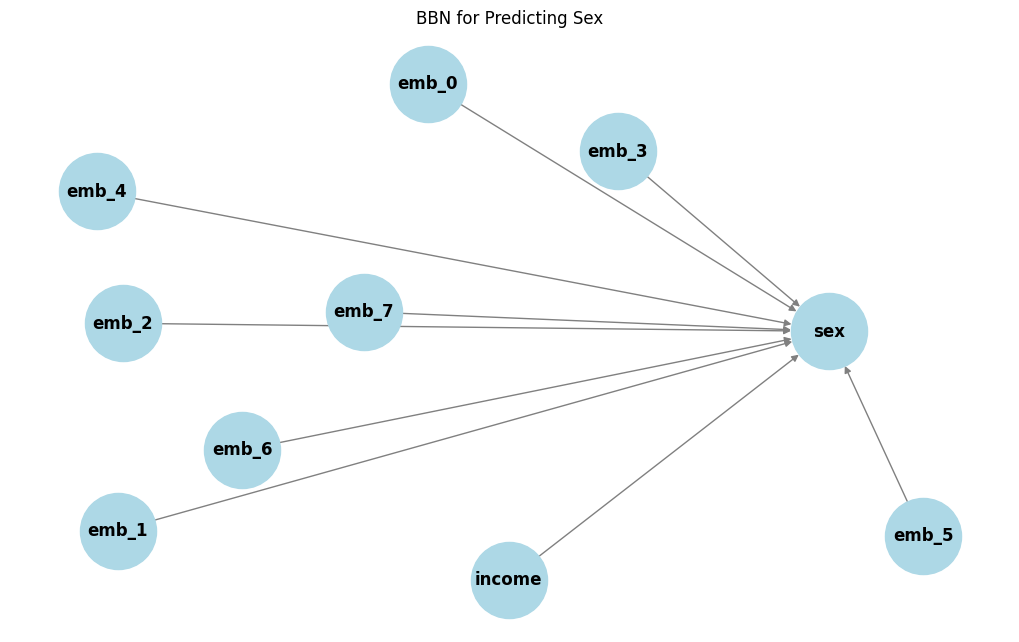

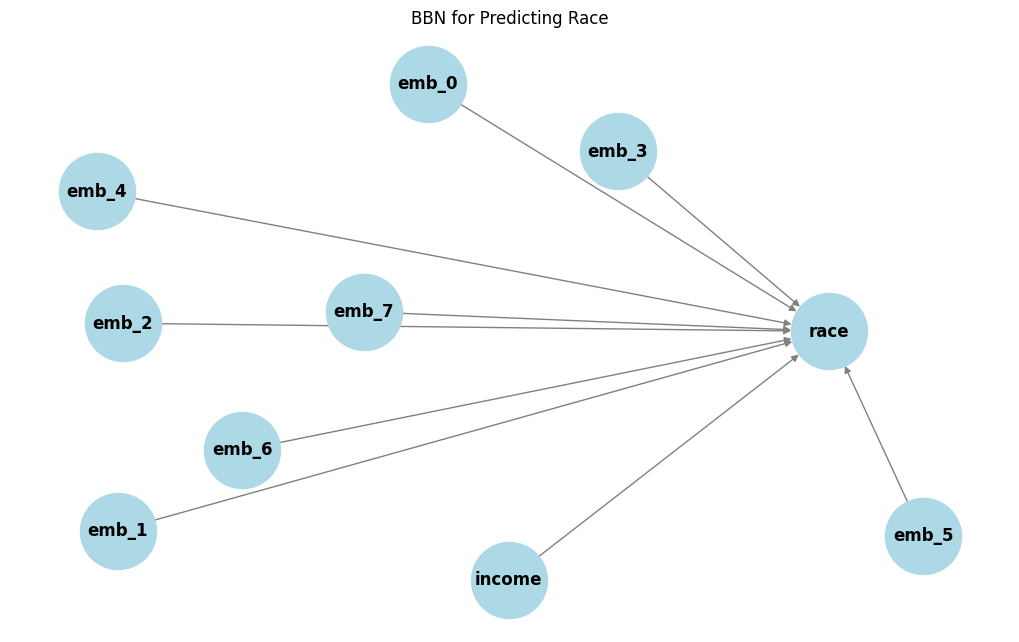

In [20]:
# Visualize and inspect the BBNs
visualize_bbn(bbn_sex, title='BBN for Predicting Sex')
visualize_bbn(bbn_race, title='BBN for Predicting Race')



**To alternate between freezing/unfreezing the encoderTo auto-learn the BBN structure instead of hardcoding it**


In [21]:
import tensorflow as tf
import numpy as np

# -------------------------------
# Adversary Loss Function (BBN)
# -------------------------------

def bbn_adversarial_loss(encoder, bbn, sensitive_batch, X_batch, y_batch, target_attr='sex'):
    embeddings = encoder(X_batch, training=False).numpy()
    loss = 0.0
    for i in range(len(X_batch)):
        predicted_dist = predict_sensitive_probs(bbn, embeddings[i], y_batch[i], target=target_attr)
        true_val = int(sensitive_batch[i])
        prob = predicted_dist.values[true_val]
        loss += -np.log(prob + 1e-8)  # cross-entropy
    return loss / len(X_batch)


# -------------------------------
# Training Setup
# -------------------------------

lambda_sex = 0.1
lambda_race = 0.1
optimizer = tf.keras.optimizers.Adam()

def train_step(X_batch, y_batch, sex_batch, race_batch):
    with tf.GradientTape() as tape:
        preds = fair_main_model(X_batch, training=True)
        y_batch = tf.reshape(y_batch, (-1, 1))
        
        # Calculate binary crossentropy loss
        pred_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_batch, preds))
        
        # Get the embeddings from the encoder
        embeddings = encoder(X_batch, training=True)
        
        # Compute the adversarial loss for sex and race using the BBN inference method
        adv_sex_loss = lambda_sex * bbn_adversarial_loss(encoder, bbn_sex, sex_batch, X_batch, y_batch, target_attr='sex')
        adv_race_loss = lambda_race * bbn_adversarial_loss(encoder, bbn_race, race_batch, X_batch, y_batch, target_attr='race')
        
        # Total loss (note that BBN losses are just scalars affecting the gradient of the main model)
        total_loss = pred_loss - adv_sex_loss - adv_race_loss  # Using negative sign for adversarial effect
        
    # Compute gradients only for the main model and encoder
    gradients = tape.gradient(total_loss, fair_main_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, fair_main_model.trainable_variables))
    
    return total_loss, pred_loss, adv_sex_loss, adv_race_loss
# -------------------------------
# Training Loop
# -------------------------------
batch_size = 128
epochs = 10
max_batches_per_epoch = 100  # Process only 100 batches per epoch

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}")
    
    # Shuffle indices for all arrays to maintain consistency
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)
    
    # Iterate over batches with a limit
    batch_count = 0
    for i in range(0, X_train.shape[0], batch_size):
        if batch_count >= max_batches_per_epoch:
            break
            
        idx = indices[i:i + batch_size]
        
        # Use idx to index the same rows in all arrays
        X_batch = tf.convert_to_tensor(X_train[idx].toarray(), dtype=tf.float32)
        y_batch = tf.convert_to_tensor(y_train[idx], dtype=tf.float32)
        sex_batch = sensitive_sex_train.iloc[idx].values
        race_batch = sensitive_race_train.iloc[idx].values
        
        loss, pred_l, adv_sex_l, adv_race_l = train_step(X_batch, y_batch, sex_batch, race_batch)
        print(f"Batch {batch_count + 1}/{max_batches_per_epoch} | Total Loss: {loss.numpy():.4f} | "
              f"Pred: {pred_l.numpy():.4f} | Adv Sex: {adv_sex_l:.4f} | Adv Race: {adv_race_l:.4f}")
        
        batch_count += 1


Epoch 1
Batch 1/100 | Total Loss: 0.6167 | Pred: 0.7221 | Adv Sex: 0.0518 | Adv Race: 0.0536
Batch 2/100 | Total Loss: 0.5780 | Pred: 0.7019 | Adv Sex: 0.0563 | Adv Race: 0.0677
Batch 3/100 | Total Loss: 0.6074 | Pred: 0.7136 | Adv Sex: 0.0528 | Adv Race: 0.0534
Batch 4/100 | Total Loss: 0.6257 | Pred: 0.7239 | Adv Sex: 0.0547 | Adv Race: 0.0435
Batch 5/100 | Total Loss: 0.5895 | Pred: 0.6899 | Adv Sex: 0.0567 | Adv Race: 0.0437
Batch 6/100 | Total Loss: 0.5976 | Pred: 0.7054 | Adv Sex: 0.0537 | Adv Race: 0.0540
Batch 7/100 | Total Loss: 0.5659 | Pred: 0.6926 | Adv Sex: 0.0586 | Adv Race: 0.0681
Batch 8/100 | Total Loss: 0.5549 | Pred: 0.6675 | Adv Sex: 0.0606 | Adv Race: 0.0520
Batch 9/100 | Total Loss: 0.5835 | Pred: 0.6798 | Adv Sex: 0.0542 | Adv Race: 0.0420
Batch 10/100 | Total Loss: 0.5807 | Pred: 0.6904 | Adv Sex: 0.0609 | Adv Race: 0.0488
Batch 11/100 | Total Loss: 0.5705 | Pred: 0.6695 | Adv Sex: 0.0547 | Adv Race: 0.0442
Batch 12/100 | Total Loss: 0.5458 | Pred: 0.6528 | Adv

In [22]:
def predict_and_evaluate_fair_model(fair_model, X_test_data, y_test_data, sensitive_race_test_data, sensitive_sex_test_data):
    # Convert sparse matrix to dense if needed
    if hasattr(X_test_data, 'toarray'):
        X_test_tensor = tf.convert_to_tensor(X_test_data.toarray(), dtype=tf.float32)
    else:
        X_test_tensor = tf.convert_to_tensor(X_test_data, dtype=tf.float32)
    
    # Get predictions from the model
    y_prob = fair_model.predict(X_test_tensor)
    y_pred = (y_prob > 0.5).astype(int).flatten()
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test_data, y_pred)
    print(f"Fair Model Accuracy: {accuracy:.4f}")
    
    # Calculate fairness metrics
    race_metrics, sex_metrics = four_metrics(y_test_data, y_pred, sensitive_race_test_data, sensitive_sex_test_data)
    
    print("\nFairness metrics for Race:")
    for metric_name, value in race_metrics.items():
        print(f"{metric_name}: {value:.4f}")
    
    print("\nFairness metrics for Sex:")
    for metric_name, value in sex_metrics.items():
        print(f"{metric_name}: {value:.4f}")
    
    return y_pred

# After training your fair model
fair_model_predictions = predict_and_evaluate_fair_model(
    fair_main_model, 
    X_test, 
    y_test, 
    sensitive_race_test, 
    sensitive_sex_test
)

284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fair Model Accuracy: 0.8354

Fairness metrics for Race:
Demographic Parity Difference: 0.3858
Equalized Odds Difference: 0.2632
Equal Opportunity Difference: 0.2632
False Positive Rate Difference: 0.2330

Fairness metrics for Sex:
Demographic Parity Difference: 0.3634
Equalized Odds Difference: 0.2287
Equal Opportunity Difference: 0.0742
False Positive Rate Difference: 0.2287


In [24]:
# def main():
#     X_train, X_test, y_train, y_test, sensitive_race_train, sensitive_race_test, sensitive_sex_train, sensitive_sex_test = preprocessAdultIncome()
    
#     base_model_pred = base_model(X_train, y_train, X_test, y_test, sensitive_race_test, sensitive_sex_test)
    
#     print("HARD STATISTICAL REWEIGHTING")
#     adjusted_hard_preds = hard_reweighting(base_model_pred, y_test, sensitive_race_test, sensitive_sex_test)
#     print("Accuracy", accuracy_score(y_test, adjusted_hard_preds))
#     met_race, met_sex = four_metrics(y_test, adjusted_hard_preds, sensitive_race_test, sensitive_sex_test)
#     print("Fairness metrics for Race:")
#     for metric_name, value in met_race.items():
#         print(f"{metric_name}: {value:.3f}")
#     print("Fairness metrics for Sex:")
#     for metric_name, value in met_sex.items():
#         print(f"{metric_name}: {value:.3f}")
    
#     print("\nTRAINING MODEL WITH BBN ADVERSARIES")
#     model, encoder, race_bbn, sex_bbn, fair_preds_binary = train_adversarial_model_bbn(
#         X_train, y_train, sensitive_race_train, sensitive_sex_train,
#         X_test, y_test, sensitive_race_test, sensitive_sex_test
#     )
    
#     print("Base model accuracy:", accuracy_score(y_test, base_model_pred))
#     print("Fair model accuracy:", accuracy_score(y_test, fair_preds_binary))
    
#     base_race_metrics, base_sex_metrics = four_metrics(y_test, base_model_pred, sensitive_race_test, sensitive_sex_test)
#     fair_race_metrics, fair_sex_metrics = four_metrics(y_test, fair_preds_binary, sensitive_race_test, sensitive_sex_test)
    
#     print("\nBase model fairness metrics for Race:")
#     for metric_name, value in base_race_metrics.items():
#         print(f"{metric_name}: {value:.3f}")
    
#     print("\nFair model fairness metrics for Race:")
#     for metric_name, value in fair_race_metrics.items():
#         print(f"{metric_name}: {value:.3f}")
    
#     print("\nBase model fairness metrics for Sex:")
#     for metric_name, value in base_sex_metrics.items():
#         print(f"{metric_name}: {value:.3f}")
    
#     print("\nFair model fairness metrics for Sex:")
#     for metric_name, value in fair_sex_metrics.items():
#         print(f"{metric_name}: {value:.3f}")
    
#     # Additional analysis of BBN structure
#     print("\nRace BBN structure:")
#     print(race_bbn.edges())
    
#     print("\nSex BBN structure:")
#     print(sex_bbn.edges())

# if __name__ == "__main__":
#     main()